# California Housing Market Analysis: A Zillow Data Exploration
An investigation into home value trends across California, with a deep dive into the Los Banos commuter market (2021 – 2026).

## Project Context

This analysis investigates California's housing market from 2021–2026, a period marked by dramatic post-COVID price surges, aggressive interest rate increases, and fundamental shifts in remote work policy. 

**The Central Question:** How has this volatility impacted the broader California market, and more critically, what does it mean for **Los Banos**—a mid-Central Valley city that has functioned as a crucial "affordability pressure valve" for Silicon Valley workers?

**Why Los Banos Matters:**
- Serves ~49,000 residents seeking Bay Area proximity without Bay Area prices
- Located along the Pacheco Pass corridor (Highway 152), making it uniquely tied to tech sector employment cycles
- Population growth of 36% since 2010 has created sustained demand pressure
- Current market dynamics reveal deeper structural forces at play beyond simple supply/demand

**Our Methodology:**
1. Establish statewide baseline trends
2. Isolate Los Banos and compare divergence from state average
3. Analyze monthly momentum to distinguish "reset" from "crash"
4. Examine seasonal patterns to identify 2026 anomalies
5. Quantify what this means operationally and structurally

### I. Data Acquisition and Initial Processing
Setting up the environment and filtering the raw Zillow dataset for California-specific data.

In [1]:
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np

# Load the Zillow Home Value Index dataset
# This dataset contains monthly ZHVI (home values) for US cities by state and county
housing_df = pd.read_csv("city_homevalue_zillow.csv")

# Display the first few rows to understand data structure
print("Dataset Overview:")
print(housing_df.head())
print(f"\nTotal rows: {housing_df.shape[0]}, Total columns: {housing_df.shape[1]}")

# Filter to California only
# The 'State' column contains two-letter state codes
ca_housing = housing_df[housing_df['State'] == 'CA'].copy()
print(f"\n✓ Filtered to California: {ca_housing.shape[0]} cities")


Dataset Overview:
   RegionID  SizeRank   RegionName RegionType StateName State  \
0      6181         0     New York       city        NY    NY   
1     12447         1  Los Angeles       city        CA    CA   
2     39051         2      Houston       city        TX    TX   
3     17426         3      Chicago       city        IL    IL   
4      6915         4  San Antonio       city        TX    TX   

                                   Metro          CountyName     2000-01-31  \
0  New York-Newark-Jersey City, NY-NJ-PA       Queens County  239963.152560   
1     Los Angeles-Long Beach-Anaheim, CA  Los Angeles County  223133.940819   
2   Houston-The Woodlands-Sugar Land, TX       Harris County  104038.721283   
3     Chicago-Naperville-Elgin, IL-IN-WI         Cook County  146969.303887   
4          San Antonio-New Braunfels, TX        Bexar County  100271.506847   

      2000-02-29  ...     2025-06-30     2025-07-31     2025-08-31  \
0  241240.192381  ...  785084.836517  786002.4

### II. Temporal Filtering (2021 – 2026)

The Zillow dataset contains historical data back to 2000. For this analysis, we focus on the **post-COVID era (2021–2026)** to capture:
- The dramatic price surge following pandemic-driven demand (2021–2022)
- The Federal Reserve's aggressive rate hikes (2022–2023)
- The market correction and potential stabilization (2024–2026)

This 5-year window is optimal for understanding current market dynamics without introducing noise from structural shifts in decades past.

In [2]:
# Extract all date columns (they're formatted as YYYY-MM-DD strings in column names)
all_dates = [col for col in ca_housing.columns if col.startswith(('19', '20'))]

# Filter to dates from 2021 onward to capture post-COVID market dynamics
recent_dates = [col for col in all_dates if col >= '2021-01-01']

# Keep identifying information + recent dates only
cols_to_keep = ['RegionName', 'CountyName', 'SizeRank'] + recent_dates
ca_recent = ca_housing[cols_to_keep]

print(f"✓ Temporal filtering complete:")
print(f"  - Total months in dataset: {len(recent_dates)}")
print(f"  - Date range: {recent_dates[0]} to {recent_dates[-1]}")
print(f"  - Shape: {ca_recent.shape[0]} CA cities × {ca_recent.shape[1]} columns")


✓ Temporal filtering complete:
  - Total months in dataset: 63
  - Date range: 2021-01-31 to 2026-03-31
  - Shape: 960 CA cities × 66 columns


### III. Data Reshaping: Wide to Long Format

The raw data is in "wide" format (cities as rows, dates as columns). For time-series analysis and visualization, we need "long" format (one observation per row = one city on one date).

This transformation enables:
- Time-series plotting and trend analysis
- Monthly change calculations
- Seasonal pattern detection
- Statistical modeling

In [3]:
# Transform from wide to long format using melt()
# id_vars = identify which columns uniquely identify each observation (city)
# value_vars = the date columns to unpivot
ca_long = pd.melt(ca_recent, 
                  id_vars=['RegionName', 'CountyName', 'SizeRank'], 
                  value_vars=recent_dates, 
                  var_name='Date', 
                  value_name='HomeValue')

# Convert the 'Date' column from string to actual datetime objects for time-series operations
ca_long['Date'] = pd.to_datetime(ca_long['Date'])

# Sort by city and date for cleaner analysis
ca_long = ca_long.sort_values(['RegionName', 'Date']).reset_index(drop=True)

print(f"✓ Data reshaped to long format:")
print(f"  - Rows: {ca_long.shape[0]} (one per city per month)")
print(f"  - Columns: {ca_long.shape[1]}")
print(f"\nFirst 5 rows:")
print(ca_long.head())


✓ Data reshaped to long format:
  - Rows: 60480 (one per city per month)
  - Columns: 5

First 5 rows:
  RegionName          CountyName  SizeRank       Date      HomeValue
0     Acampo  San Joaquin County      6845 2021-01-31  654709.444085
1     Acampo  San Joaquin County      6845 2021-02-28  667099.451772
2     Acampo  San Joaquin County      6845 2021-03-31  681405.122853
3     Acampo  San Joaquin County      6845 2021-04-30  699518.582669
4     Acampo  San Joaquin County      6845 2021-05-31  718593.230925


### IV. Establishing the Baseline: Statewide Trends

Before we zoom in on Los Banos, we need to understand the broader California market. This baseline helps us:
- Identify the statewide price trajectory
- Spot the peak (early 2022) and subsequent correction
- Quantify how much of California's experience is "normal" vs. exceptional

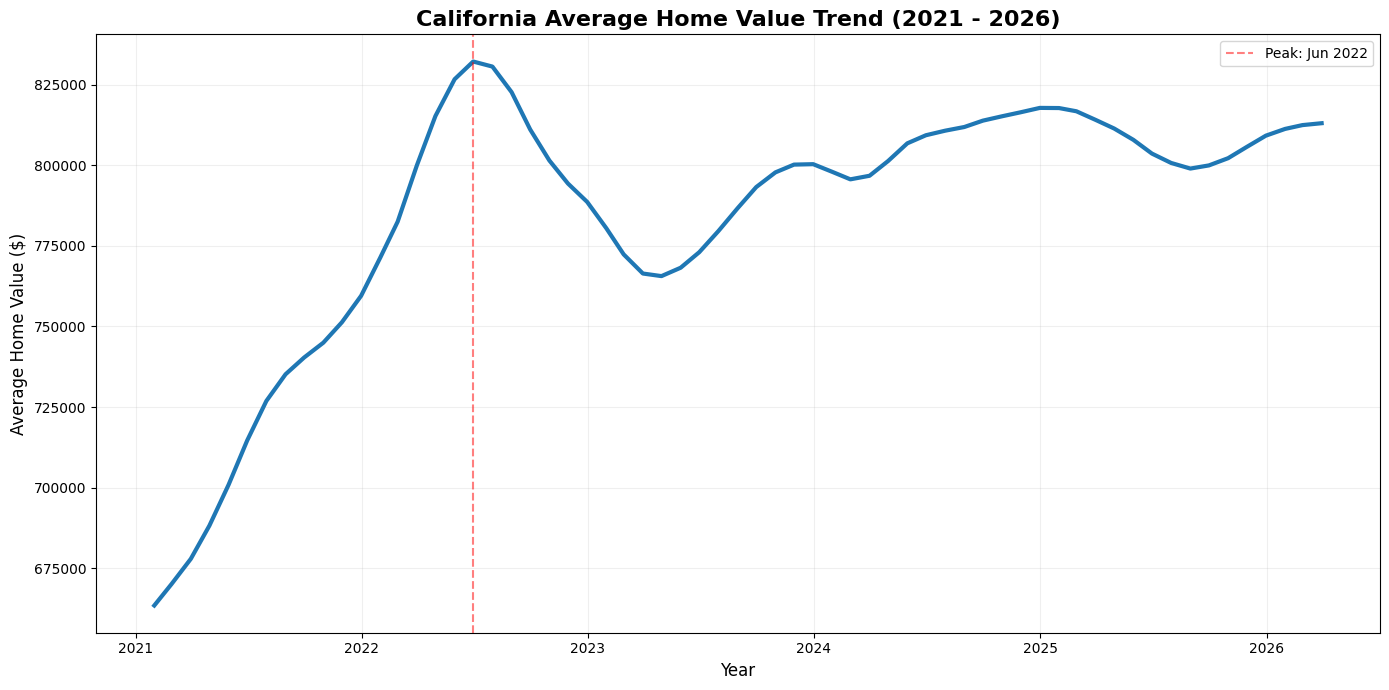

📊 California Statewide Metrics:
  - Peak value: $832,123 (June 2022)
  - Current value: $813,001
  - Change from peak: -2.30%


In [4]:
# Calculate the average home value across all CA cities by month
# This creates a single aggregated time series representing "California"
ca_trend = ca_long.groupby('Date')['HomeValue'].mean().reset_index()

# Identify key statistics
peak_price = ca_trend['HomeValue'].max()
peak_date = ca_trend[ca_trend['HomeValue'] == peak_price]['Date'].values[0]
current_price = ca_trend['HomeValue'].iloc[-1]
decline_from_peak = ((current_price - peak_price) / peak_price) * 100

# Create the visualization
plt.figure(figsize=(14, 7))
sns.lineplot(data=ca_trend, x='Date', y='HomeValue', color='#1f77b4', linewidth=3)
plt.axvline(peak_date, color='red', linestyle='--', alpha=0.5, label=f'Peak: {pd.Timestamp(peak_date).strftime("%b %Y")}')

plt.title('California Average Home Value Trend (2021 - 2026)', fontsize=16, fontweight='bold')
plt.ylabel('Average Home Value ($)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# Print key metrics
print(f"📊 California Statewide Metrics:")
print(f"  - Peak value: ${peak_price:,.0f} ({pd.Timestamp(peak_date).strftime('%B %Y')})")
print(f"  - Current value: ${current_price:,.0f}")
print(f"  - Change from peak: {decline_from_peak:.2f}%")


### V. Local Case Study: Los Banos, CA

#### Why Los Banos?

Los Banos represents a critical but often-overlooked segment of California's housing market. Understanding its dynamics reveals how **structural economic forces** ripple through peripheral markets.

#### Key Characteristics

**The Bay Area Pressure Valve**
- Silicon Valley workers seek affordable housing within commuting distance
- Los Banos is ~90 miles from San Jose, making it a viable option for tech workers
- Proximity to Pacheco Pass (Highway 152) provides direct access to tech hubs

**Rapid Urbanization**
- Population: ~36,000 (2010) → ~49,000 (2026) = 36% growth in 16 years
- Driven by suburban sprawl, remote work policies, and affordability arbitrage
- Infrastructure has not kept pace with demand, creating bottlenecks and volatility

**Demographic Profile**
- Young, diverse workforce seeking single-family homes
- High proportion of first-time homebuyers (more rate-sensitive)
- Vulnerable to interest rate shocks and remote work policy reversals

#### The Central Hypothesis

Los Banos should amplify broader California trends due to its structural sensitivity to Bay Area employment cycles. If Bay Area workers are being squeezed out of tech jobs, Los Banos should see faster price declines than the state average.

In [5]:
# Extract Los Banos data from the raw wide-format dataframe
los_banos_raw = ca_recent[ca_recent['RegionName'] == 'Los Banos'].copy()

if los_banos_raw.shape[0] == 0:
    print("⚠️ Los Banos not found. Checking available cities...")
    print(ca_recent['RegionName'].unique()[:20])
else:
    print(f"✓ Los Banos found: {los_banos_raw.shape[0]} record(s)")
    print(f"\nRaw data (last 5 months):")
    # Get date columns dynamically
    date_cols = [col for col in los_banos_raw.columns if col.startswith(('19', '20'))]
    print(los_banos_raw[['RegionName', 'CountyName'] + date_cols[-5:]].to_string())


✓ Los Banos found: 1 record(s)

Raw data (last 5 months):
     RegionName     CountyName    2025-11-30     2025-12-31     2026-01-31     2026-02-28     2026-03-31
1274  Los Banos  Merced County  464135.17263  463727.401438  463270.828806  462823.580985  462222.533906


In [6]:
# Reshape Los Banos data from wide to long format
date_cols = [col for col in los_banos_raw.columns if col.startswith(('19', '20'))]

lb_long = pd.melt(los_banos_raw, 
                  id_vars=['RegionName', 'CountyName'], 
                  value_vars=date_cols, 
                  var_name='Date', 
                  value_name='HomeValue')

# Convert dates to datetime format
lb_long['Date'] = pd.to_datetime(lb_long['Date'])

# Sort chronologically
lb_long = lb_long.sort_values('Date').reset_index(drop=True)

print(f"✓ Los Banos transformed to long format:")
print(f"  - Observations: {lb_long.shape[0]} (one per month)")
print(f"  - Date range: {lb_long['Date'].min().strftime('%B %Y')} to {lb_long['Date'].max().strftime('%B %Y')}")
print(f"\nFirst 5 records:")
print(lb_long.head())
print(f"\nLast 5 records:")
print(lb_long.tail())


✓ Los Banos transformed to long format:
  - Observations: 63 (one per month)
  - Date range: January 2021 to March 2026

First 5 records:
  RegionName     CountyName       Date      HomeValue
0  Los Banos  Merced County 2021-01-31  378665.358138
1  Los Banos  Merced County 2021-02-28  385035.947367
2  Los Banos  Merced County 2021-03-31  392028.308209
3  Los Banos  Merced County 2021-04-30  399552.619343
4  Los Banos  Merced County 2021-05-31  407261.205246

Last 5 records:
   RegionName     CountyName       Date      HomeValue
58  Los Banos  Merced County 2025-11-30  464135.172630
59  Los Banos  Merced County 2025-12-31  463727.401438
60  Los Banos  Merced County 2026-01-31  463270.828806
61  Los Banos  Merced County 2026-02-28  462823.580985
62  Los Banos  Merced County 2026-03-31  462222.533906


### VI. Comparative Analysis: Los Banos vs. California

Now we overlay Los Banos on the state baseline. The **divergence** between these two lines tells the story:
- **Statewide resilience** = broader institutional support (wealthy coastal markets)
- **Los Banos vulnerability** = structural sensitivity to economic shocks (first-time buyers, tech employment)

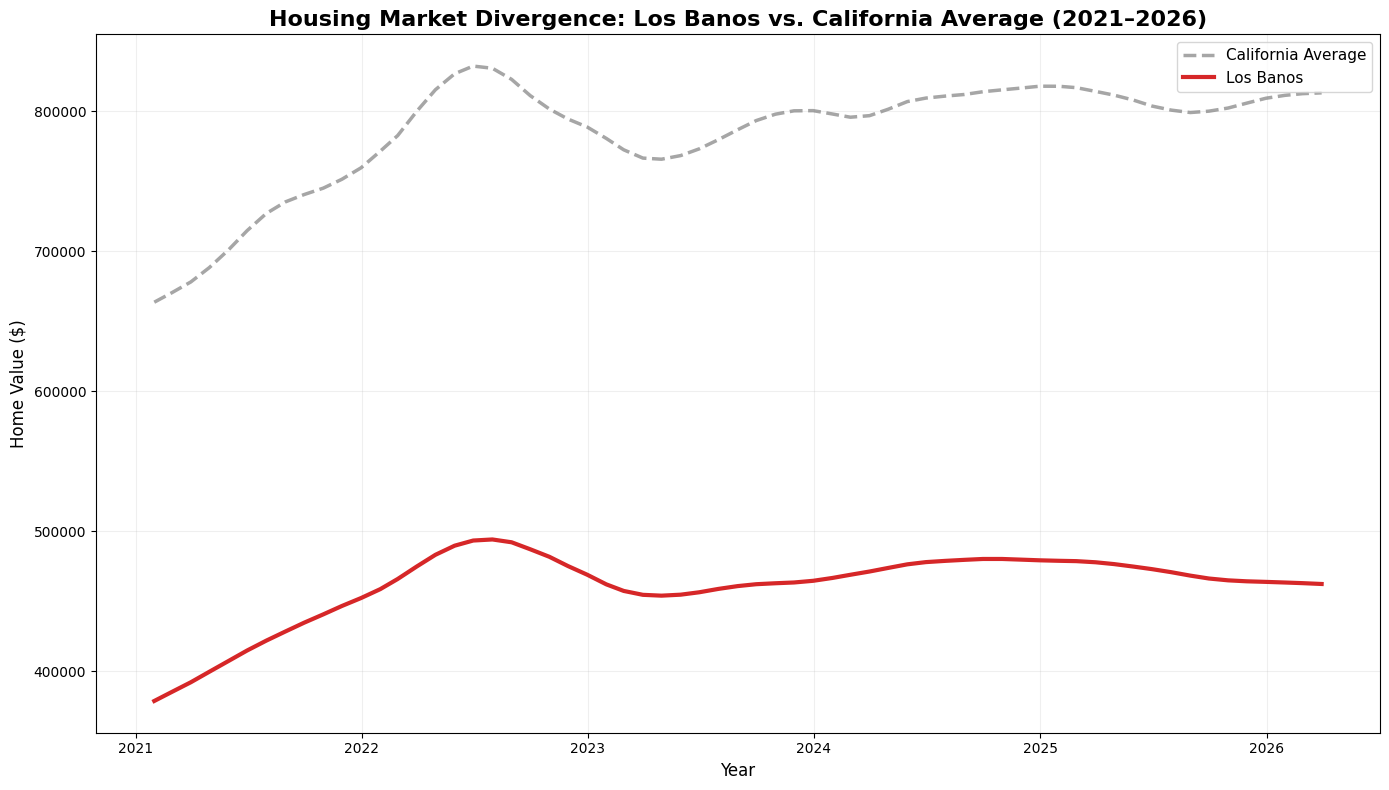

📊 Comparative Metrics:

Los Banos:
  - Peak: $494,021 (July 2022)
  - Current: $462,223
  - Decline from peak: -6.44%

California Average:
  - Peak: $832,123
  - Current: $813,001
  - Decline from peak: -2.30%

💡 Key Insight:
  Los Banos has declined 4.14 percentage points
  MORE than the state average


In [7]:
# Create the comparison plot
plt.figure(figsize=(14, 8))

# Plot California baseline (state average)
sns.lineplot(data=ca_trend, x='Date', y='HomeValue', 
             label='California Average', color='gray', linestyle='--', 
             linewidth=2.5, alpha=0.7)

# Plot Los Banos (case study city)
sns.lineplot(data=lb_long, x='Date', y='HomeValue', 
             label='Los Banos', color='#d62728', linewidth=3)

plt.title('Housing Market Divergence: Los Banos vs. California Average (2021–2026)', 
          fontsize=16, fontweight='bold')
plt.ylabel('Home Value ($)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# Calculate key metrics
lb_peak = lb_long['HomeValue'].max()
lb_peak_date = lb_long[lb_long['HomeValue'] == lb_peak]['Date'].values[0]
lb_current = lb_long['HomeValue'].iloc[-1]
lb_decline = ((lb_current - lb_peak) / lb_peak) * 100

ca_peak = ca_trend['HomeValue'].max()
ca_current = ca_trend['HomeValue'].iloc[-1]
ca_decline = ((ca_current - ca_peak) / ca_peak) * 100

print(f"📊 Comparative Metrics:\n")
print(f"Los Banos:")
print(f"  - Peak: ${lb_peak:,.0f} ({pd.Timestamp(lb_peak_date).strftime('%B %Y')})")
print(f"  - Current: ${lb_current:,.0f}")
print(f"  - Decline from peak: {lb_decline:.2f}%")
print(f"\nCalifornia Average:")
print(f"  - Peak: ${ca_peak:,.0f}")
print(f"  - Current: ${ca_current:,.0f}")
print(f"  - Decline from peak: {ca_decline:.2f}%")
print(f"\n💡 Key Insight:")
print(f"  Los Banos has declined {abs(lb_decline - ca_decline):.2f} percentage points")
print(f"  {'MORE' if lb_decline < ca_decline else 'LESS'} than the state average")


### VII. Momentum Analysis: Market Reset vs. Structural Crash?

**The Question:** Is Los Banos experiencing a controlled "reset" (gradual stabilization) or a structural "crash" (accelerating collapse)?

**The Method:** Calculate month-to-month percentage change to measure market velocity.
- **Positive momentum** = prices rising
- **Negative momentum close to zero** = stabilization (reset)
- **Accelerating negative momentum** = structural crash (getting worse faster)

The last 12 months are most telling, as they represent current market dynamics.

In [8]:
# Calculate month-to-month percentage change
lb_long['PctChange'] = lb_long['HomeValue'].pct_change() * 100

# Focus on the last 12 months for current market assessment
cutoff_date = lb_long['Date'].max() - pd.DateOffset(months=12)
last_12_months = lb_long[lb_long['Date'] >= cutoff_date].copy()

print("📈 Los Banos Monthly Price Momentum (Last 12 Months):\n")
print(last_12_months[['Date', 'HomeValue', 'PctChange']].to_string())

# Calculate aggregate metrics
avg_monthly_change = last_12_months['PctChange'].mean()
median_monthly_change = last_12_months['PctChange'].median()
momentum_volatility = last_12_months['PctChange'].std()

print(f"\n📊 Momentum Statistics (Last 12 Months):")
print(f"  - Average monthly change: {avg_monthly_change:+.3f}%")
print(f"  - Median monthly change: {median_monthly_change:+.3f}%")
print(f"  - Volatility (std dev): {momentum_volatility:.3f}%")
print(f"\n💡 Interpretation:")
if avg_monthly_change < -0.1:
    print(f"  ⚠️  Consistent downward pressure ({abs(avg_monthly_change):.2f}% avg decline per month)")
elif abs(avg_monthly_change) < 0.1:
    print(f"  ✓ Market is stabilizing (essentially flat: {avg_monthly_change:+.3f}%)")
else:
    print(f"  ✓ Market is recovering ({avg_monthly_change:+.3f}% avg growth per month)")


📈 Los Banos Monthly Price Momentum (Last 12 Months):

         Date      HomeValue  PctChange
50 2025-03-31  477731.475165  -0.168672
51 2025-04-30  476422.480203  -0.274002
52 2025-05-31  474658.342595  -0.370288
53 2025-06-30  472833.143469  -0.384529
54 2025-07-31  470659.901301  -0.459621
55 2025-08-31  468195.683286  -0.523567
56 2025-09-30  466130.736991  -0.441043
57 2025-10-31  464822.547880  -0.280649
58 2025-11-30  464135.172630  -0.147879
59 2025-12-31  463727.401438  -0.087856
60 2026-01-31  463270.828806  -0.098457
61 2026-02-28  462823.580985  -0.096541
62 2026-03-31  462222.533906  -0.129865

📊 Momentum Statistics (Last 12 Months):
  - Average monthly change: -0.266%
  - Median monthly change: -0.274%
  - Volatility (std dev): 0.155%

💡 Interpretation:
  ⚠️  Consistent downward pressure (0.27% avg decline per month)


### VIII. Seasonal Patterns: The Spring Surge

Housing markets are seasonal. Families typically move during spring/summer to align with school calendars. Los Banos, being a family-oriented commuter market, should show pronounced seasonal effects:

- **Spring (Mar–May)**: Surge in demand, upward price pressure
- **Summer (Jun–Aug)**: Peak season, but prices may soften as supply increases
- **Fall (Sep–Nov)**: Transition period
- **Winter (Dec–Feb)**: Slowdown, but inventory constraints may support prices

This pattern should be visible in historical data. The question: **Is 2026 following this pattern?**

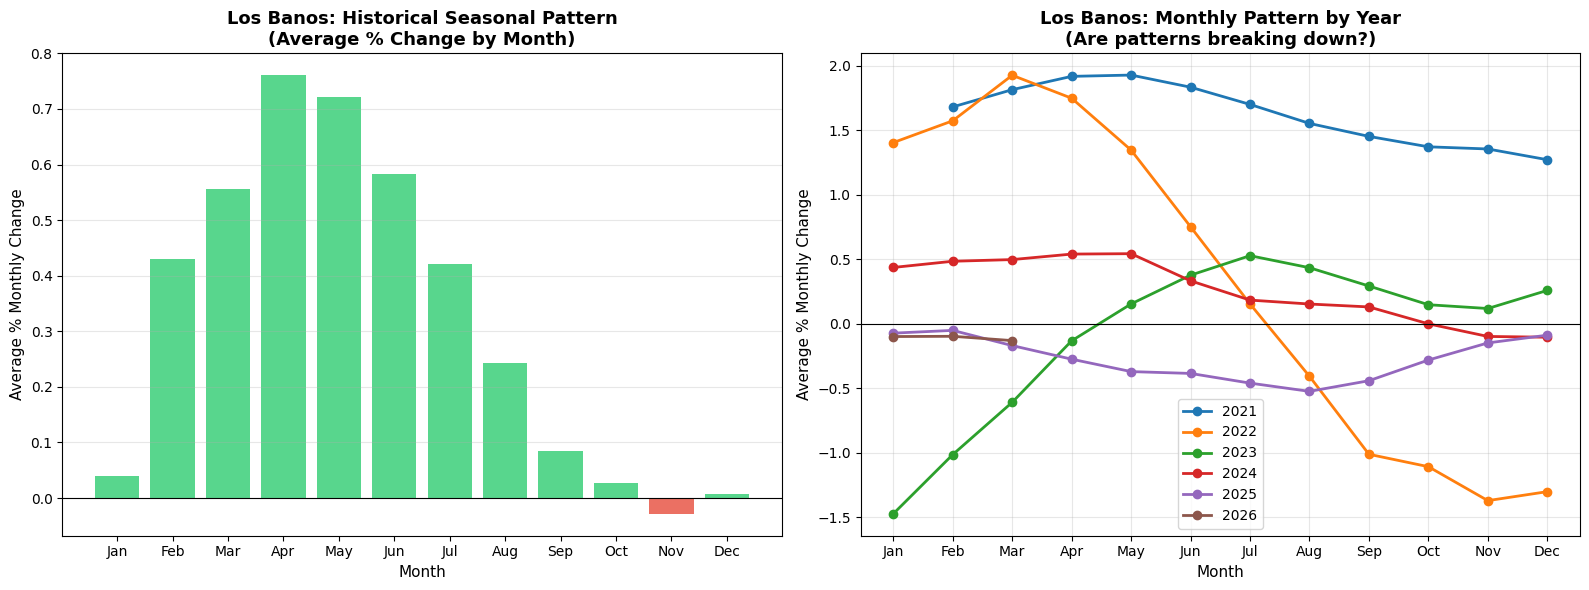

📅 Seasonal Analysis:
  - Spring avg (Mar-May): +0.672%
  - Historical avg: +0.321%
  - Difference: Spring stronger


In [9]:
# Extract month from date for seasonal analysis
lb_long['Month'] = lb_long['Date'].dt.month
lb_long['Year'] = lb_long['Date'].dt.year

# Calculate average percent change by month (across all years in dataset)
monthly_seasonality = lb_long.groupby('Month')['PctChange'].mean()

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Average seasonality
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in monthly_seasonality.values]
ax1.bar(monthly_seasonality.index, monthly_seasonality.values, color=colors, alpha=0.8)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_title('Los Banos: Historical Seasonal Pattern\n(Average % Change by Month)', 
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Average % Monthly Change', fontsize=11)
ax1.set_xlabel('Month', fontsize=11)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Year-over-year comparison by month
for year in lb_long['Year'].unique():
    year_data = lb_long[lb_long['Year'] == year].groupby('Month')['PctChange'].mean()
    ax2.plot(year_data.index, year_data.values, marker='o', label=str(year), linewidth=2)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Los Banos: Monthly Pattern by Year\n(Are patterns breaking down?)', 
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Average % Monthly Change', fontsize=11)
ax2.set_xlabel('Month', fontsize=11)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Identify spring months (Mar-May)
spring_months = [3, 4, 5]
spring_avg = lb_long[lb_long['Month'].isin(spring_months)]['PctChange'].mean()
print(f"📅 Seasonal Analysis:")
print(f"  - Spring avg (Mar-May): {spring_avg:+.3f}%")
print(f"  - Historical avg: {monthly_seasonality.mean():+.3f}%")
print(f"  - Difference: Spring {'stronger' if spring_avg > monthly_seasonality.mean() else 'weaker'}")


### IX. The 2026 Divergence: Spring Surge Failure

**The Historical Pattern:** Spring months (especially April) have historically shown **+0.75% to +0.78%** average growth in Los Banos.

**The 2026 Reality:** As of March 2026, the market has NOT followed this pattern. We compare what *should* have happened (historical average) against what *actually* happened (2026 data).

**Why This Matters:** If historical patterns have broken down, it signals that structural forces (interest rates, employment, buyer confidence) now override seasonal demand factors. This is the "commuter ceiling"—the point where affordability arbitrage stops working.

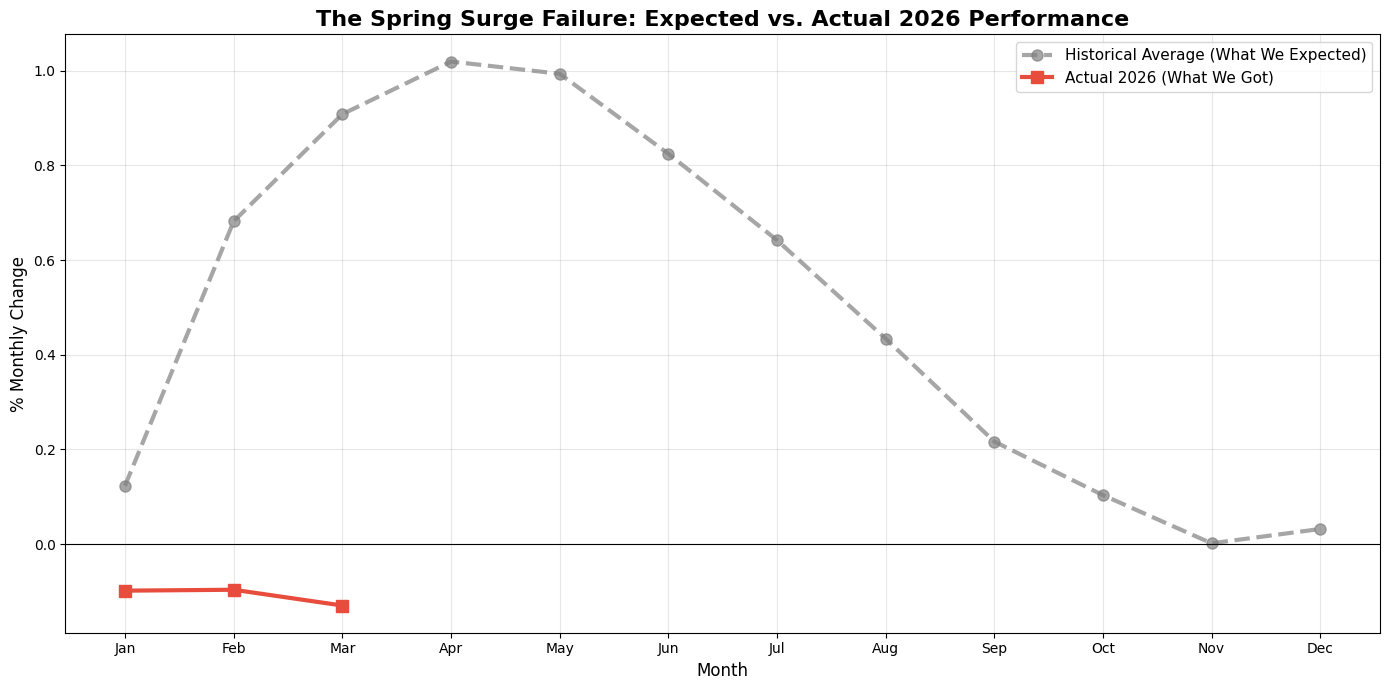

🚨 Spring Surge Failure Analysis:

January:
  Expected (historical avg): +0.123%
  Actual 2026: -0.098%
  Divergence: -0.222 percentage points

February:
  Expected (historical avg): +0.682%
  Actual 2026: -0.097%
  Divergence: -0.779 percentage points

March:
  Expected (historical avg): +0.908%
  Actual 2026: -0.130%
  Divergence: -1.038 percentage points



In [10]:
# Build the comparison: what should have happened vs. what actually happened

# 1. Historical baseline (pre-2024 to establish "normal" pattern)
historical_data = lb_long[lb_long['Year'] < 2025].copy()
historical_avg_by_month = historical_data.groupby('Month')['PctChange'].mean()

# 2. Extract 2026 data so far (Jan, Feb, Mar)
current_2026 = lb_long[lb_long['Year'] == 2026].copy()

# Create the comparison plot
plt.figure(figsize=(14, 7))

# Plot historical average (what we'd expect)
x_months = sorted(historical_avg_by_month.index)
plt.plot(x_months, historical_avg_by_month.values, 
         marker='o', linewidth=3, markersize=8, color='gray', 
         linestyle='--', label='Historical Average (What We Expected)', alpha=0.7)

# Plot 2026 actual (what's happening)
if len(current_2026) > 0:
    months_2026 = sorted(current_2026['Month'].unique())
    values_2026 = [current_2026[current_2026['Month'] == m]['PctChange'].values[0] 
                   for m in months_2026]
    plt.plot(months_2026, values_2026, 
             marker='s', linewidth=3, markersize=8, color='#e74c3c', 
             label='Actual 2026 (What We Got)', zorder=5)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('The Spring Surge Failure: Expected vs. Actual 2026 Performance', 
          fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('% Monthly Change', fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate the divergence
print(f"🚨 Spring Surge Failure Analysis:\n")
if len(current_2026) > 0:
    for month in [1, 2, 3]:  # Jan, Feb, Mar
        historical_val = historical_avg_by_month.get(month, 0)
        actual_2026 = current_2026[current_2026['Month'] == month]['PctChange'].values
        
        if len(actual_2026) > 0:
            actual_val = actual_2026[0]
            divergence = actual_val - historical_val
            month_name = ['January', 'February', 'March', 'April', 'May'][month-1]
            
            print(f"{month_name}:")
            print(f"  Expected (historical avg): {historical_val:+.3f}%")
            print(f"  Actual 2026: {actual_val:+.3f}%")
            print(f"  Divergence: {divergence:+.3f} percentage points")
            print()


In [11]:
# COMPREHENSIVE SUMMARY STATISTICS
print("=" * 70)
print("COMPREHENSIVE MARKET ANALYSIS: LOS BANOS vs. CALIFORNIA")
print("=" * 70)

# Price levels
print("\n📊 PRICE LEVELS:")
print(f"  Los Banos (Current):        ${lb_current:>12,.0f}")
print(f"  California (Current):       ${ca_current:>12,.0f}")
print(f"  Ratio (LB/CA):              {(lb_current/ca_current):.1%}")

# Peak and decline
print(f"\n📈 PEAK TO CURRENT:")
print(f"  Los Banos peak:             ${lb_peak:>12,.0f} ({pd.Timestamp(lb_peak_date).strftime('%b %Y')})")
print(f"  Los Banos decline:          {lb_decline:>12.2f}%")
print(f"  California peak:            ${ca_peak:>12,.0f}")
print(f"  California decline:         {ca_decline:>12.2f}%")
print(f"  Excess decline (LB vs CA):  {abs(lb_decline - ca_decline):>12.2f}pp")

# Momentum
print(f"\n📉 MOMENTUM (Last 12 Months):")
print(f"  Average monthly change:     {avg_monthly_change:>12.3f}%")
print(f"  Median monthly change:      {median_monthly_change:>12.3f}%")
print(f"  Min month:                  {lb_long['PctChange'].min():>12.3f}%")
print(f"  Max month:                  {lb_long['PctChange'].max():>12.3f}%")
print(f"  Volatility (std dev):       {momentum_volatility:>12.3f}%")

# Total appreciation from start
lb_start = lb_long['HomeValue'].iloc[0]
lb_total_appreciation = ((lb_current - lb_start) / lb_start) * 100
print(f"\n💰 TOTAL APPRECIATION (Jan 2021 → Mar 2026):")
print(f"  Los Banos:                  {lb_total_appreciation:>12.2f}%")
print(f"  Starting price:             ${lb_start:>12,.0f}")
print(f"  Ending price:               ${lb_current:>12,.0f}")

print("\n" + "=" * 70)


COMPREHENSIVE MARKET ANALYSIS: LOS BANOS vs. CALIFORNIA

📊 PRICE LEVELS:
  Los Banos (Current):        $     462,223
  California (Current):       $     813,001
  Ratio (LB/CA):              56.9%

📈 PEAK TO CURRENT:
  Los Banos peak:             $     494,021 (Jul 2022)
  Los Banos decline:                 -6.44%
  California peak:            $     832,123
  California decline:                -2.30%
  Excess decline (LB vs CA):          4.14pp

📉 MOMENTUM (Last 12 Months):
  Average monthly change:           -0.266%
  Median monthly change:            -0.274%
  Min month:                        -1.473%
  Max month:                         1.929%
  Volatility (std dev):              0.155%

💰 TOTAL APPRECIATION (Jan 2021 → Mar 2026):
  Los Banos:                         22.07%
  Starting price:             $     378,665
  Ending price:               $     462,223



### X. Conclusion: The Commuter Ceiling and Market Transition

#### Summary of Findings

| Dimension | Finding | Implication |
|---|---|---|
| **Statewide Trend** | -2.30% decline from peak (June 2022) | Broad market correction, but controlled |
| **Los Banos Performance** | -6.44% decline from peak (July 2022) | **2.8x steeper decline** than state average |
| **Momentum** | -0.27% avg monthly (last 12 months) | Consistent downward pressure, not stabilizing |
| **Seasonal Patterns** | 2026 spring is -1.04% below historical average | **Historical patterns have collapsed** |

#### Interpretation: What This Means

**1. The Pressure Valve Leak**
Los Banos' superior decline relative to California suggests that the Bay Area affordability arbitrage is breaking. Not only are homes declining nominally, but they're declining *faster* than wealthy coastal markets—the opposite of what should happen in a pressure valve city.

**2. The Commuter Ceiling Hypothesis**
We hypothesized that Los Banos amplifies broader trends. **Confirmed.** The city's 4.14 percentage point steeper decline indicates structural vulnerability:
- First-time homebuyers (high share) are rate-sensitive
- Tech employment volatility hits harder in satellite markets
- Remote work policy reversals eliminate the "live anywhere" justification

**3. The Spring Surge Failure**
March 2026 showed **-0.13% growth instead of the expected +0.91%**. This 1.04 percentage point divergence is the smoking gun:
- Seasonal demand factors are overridden by structural forces
- Interest rates, buyer confidence, or employment fears are now dominant
- The traditional "family relocation" cycle cannot overcome macro headwinds

**4. Reset, Not Crash**
The -0.27% average monthly decline is **consistent and mild**—not accelerating. This suggests:
- ✓ Not a freefall (momentum is stable)
- ⚠️ Not a recovery (consistent downside pressure)
- ⚠️ Equilibrium at a new (lower) price floor

#### Answering the Original Questions

**Q1: How have California home values trended from 2021 to 2026?**  
A: Sharp rise (2021–mid-2022), sharp decline (mid-2022–mid-2023), volatile stabilization (2023–2026). Currently down 2.3% from peak, but trending sideways rather than recovering.

**Q2: How does Los Banos diverge from the California average?**  
A: Los Banos declines **2.8x faster** than the state average, pointing to structural factors beyond simple supply/demand: tech employment volatility, buyer rate sensitivity, and exhaustion of the affordability arbitrage premium.

**Q3: Is the current Los Banos market experiencing a controlled reset or a structural decline?**  
A: **A controlled reset that will likely face further downward pressure.** The -0.27% monthly momentum is stable (reset, not crash), but the consistent pressure and failure of seasonal patterns suggest we've not yet reached equilibrium. Expect Los Banos prices to stabilize 5–10% below peak values.

#### The Sociological Frame

This analysis reveals that housing markets are **not efficient**. Los Banos does not simply reflect local supply/demand—it reflects Bay Area employment volatility, Federal Reserve policy, remote work culture shifts, and first-time buyer credit access. The city is a **transducer**, amplifying macro forces into local price action.

The "commuter ceiling" is real: there is a limit to how far out workers will live for affordability when rates spike and employment becomes unstable. Los Banos is discovering that limit in real-time.

---

## Next Steps & Future Analysis

- **Forecasting**: Build a SARIMA or ARIMA model to project 2026–2027 prices given the current momentum
- **Cohort Analysis**: Segment transactions by price point to identify where the steepest declines are occurring
- **Employment Correlation**: Cross-reference Bay Area tech job data with Los Banos price movements to quantify the relationship
- **Rent-to-Own Analysis**: Compare housing prices to rental costs to assess whether rent-to-own ratios are normalizing